In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2023-12-09 12:50:00,4.95,12680.0,France


In [5]:
df.shape


(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


## Dataset Information

- The dataset contains **541,909 rows** and **8 columns**.
- It includes transaction details such as invoice number, product code, product description, quantity, invoice date, unit price, customer ID, and country.
- The **Description** column contains **1,454 missing values**.
- The **CustomerID** column contains **135,080 missing values**.
- Quantity is stored as an integer, UnitPrice and CustomerID are stored as float values, while the remaining columns are stored as string (object) data types.
- The dataset uses approximately **69.3 MB** of memory.

In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Summary Statistics

- The average quantity purchased per transaction is **9.55**.
- The average unit price is **4.61**.
- The CustomerID column contains missing values.
- The minimum quantity (-80995) and minimum unit price (-11062.06) indicate unusual records such as returned or cancelled transactions.
- The maximum quantity is **80995**, while the maximum unit price is **38970**.
- The dataset contains both small and very large transaction values.

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Missing Values

- The dataset contains missing values only in the **Description** and **CustomerID** columns.
- The **Description** column has **1,454** missing values.
- The **CustomerID** column has **135,080** missing values.
- All other columns do not contain any missing values.
- These missing values will be handled during the data preprocessing stage.

In [10]:
df.duplicated().sum()

np.int64(5268)

## Duplicate Records

- The dataset contains **5,268 duplicate rows**.
- Duplicate records may occur due to repeated transactions or data entry issues.
- These duplicate rows will be removed during the data preprocessing stage to improve data quality.

In [11]:
df[df["InvoiceNo"].astype(str).str.startswith("C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2022-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2022-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2022-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2023-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2023-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2023-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2023-12-09 11:58:00,1.25,17315.0,United Kingdom


In [12]:
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2022-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2022-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2022-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2023-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2023-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2023-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2023-12-09 11:58:00,1.25,17315.0,United Kingdom


In [13]:
df[df["Quantity"] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [14]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2023-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2023-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [15]:
df[df["UnitPrice"] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2022-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2022-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2022-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2022-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2022-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2023-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2023-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2023-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2023-12-08 14:06:00,0.0,NaN,United Kingdom


In [16]:
df[df["InvoiceNo"].astype(str).str.startswith("C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2022-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2022-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2022-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2023-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2023-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2023-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2023-12-09 11:58:00,1.25,17315.0,United Kingdom


## Cancelled Invoices

- Invoice numbers starting with **'C'** represent cancelled transactions.
- These records will be removed during data preprocessing because they do not represent successful purchases.

## Zero Quantity

- No records were found with a quantity equal to zero.

## Negative Quantity

- The dataset contains **10,624 records** with negative quantities.
- Negative quantities indicate returned or cancelled products.
- These records will be removed during preprocessing.

## Negative Unit Price

- Only **2 records** have negative unit prices.
- These records are considered invalid and will be removed during preprocessing.

## Zero Unit Price

- Some records have a unit price equal to zero.
- These records do not contribute to revenue analysis and will be removed during preprocessing.

In [17]:
df_clean = df.copy()

In [18]:
df_clean.shape

(541909, 8)

In [19]:
df_clean = df_clean.dropna(subset=["CustomerID"])

In [20]:
df_clean.shape

(406829, 8)

## Removing Missing CustomerID

- Rows with missing **CustomerID** values were removed.
- CustomerID is essential for identifying unique customers and performing customer segmentation.
- After removing missing CustomerID values, the dataset size was reduced.

In [21]:
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

In [22]:
df_clean.shape

(397924, 8)

## Removing Cancelled Invoices

- Cancelled invoices were identified by invoice numbers starting with **'C'**.
- These transactions were removed because they do not represent completed purchases.

In [23]:
df_clean = df_clean[df_clean["Quantity"] > 0]

In [24]:
df_clean.shape

(397924, 8)

## Removing Invalid Quantity

- Records with negative or zero quantities were removed.
- These records represent returned items or invalid transactions.

In [25]:
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [26]:
df_clean.shape

(397884, 8)

## Removing Invalid Unit Prices

- Records with negative or zero unit prices were removed.
- These records do not contribute to meaningful sales analysis.

## Data Preprocessing Summary

The following preprocessing steps were performed:

1. Removed rows with missing **CustomerID** values.
2. Excluded cancelled invoices whose InvoiceNo starts with **'C'**.
3. Removed records with negative or zero quantities.
4. Removed records with negative or zero unit prices.

### Dataset Size After Each Step

| Step | Shape |
|------|--------|
| Original Dataset | (541909, 8) |
| After Removing Missing CustomerID | (406829, 8) |
| After Removing Cancelled Invoices | (397924, 8) |
| After Removing Invalid Quantities | (397924, 8) |
| After Removing Invalid Prices | (397884, 8) |

In [27]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [28]:
df_clean["InvoiceDate"].dtype

dtype('<M8[us]')

In [29]:
df_clean = df_clean.drop_duplicates()

In [30]:
df_clean.shape

(392692, 8)

In [31]:
df_clean.to_csv("cleaned_online_retail.csv", index=False)

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Makes plots look cleaner
plt.style.use("ggplot")

In [33]:
country_transactions = df_clean["Country"].value_counts()

country_transactions.head(10)

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

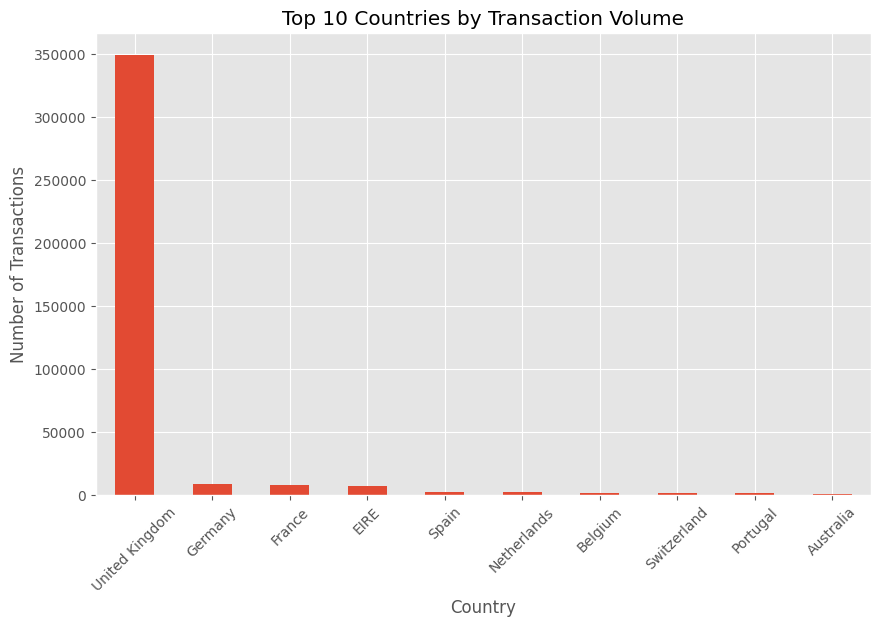

In [34]:
plt.figure(figsize=(10,6))

country_transactions.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Transaction Volume")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

## Transaction Volume by Country

- The chart shows the top 10 countries with the highest number of transactions.
- The United Kingdom has the highest transaction volume.
- This indicates that most customers belong to the UK.

In [35]:
top_products = df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

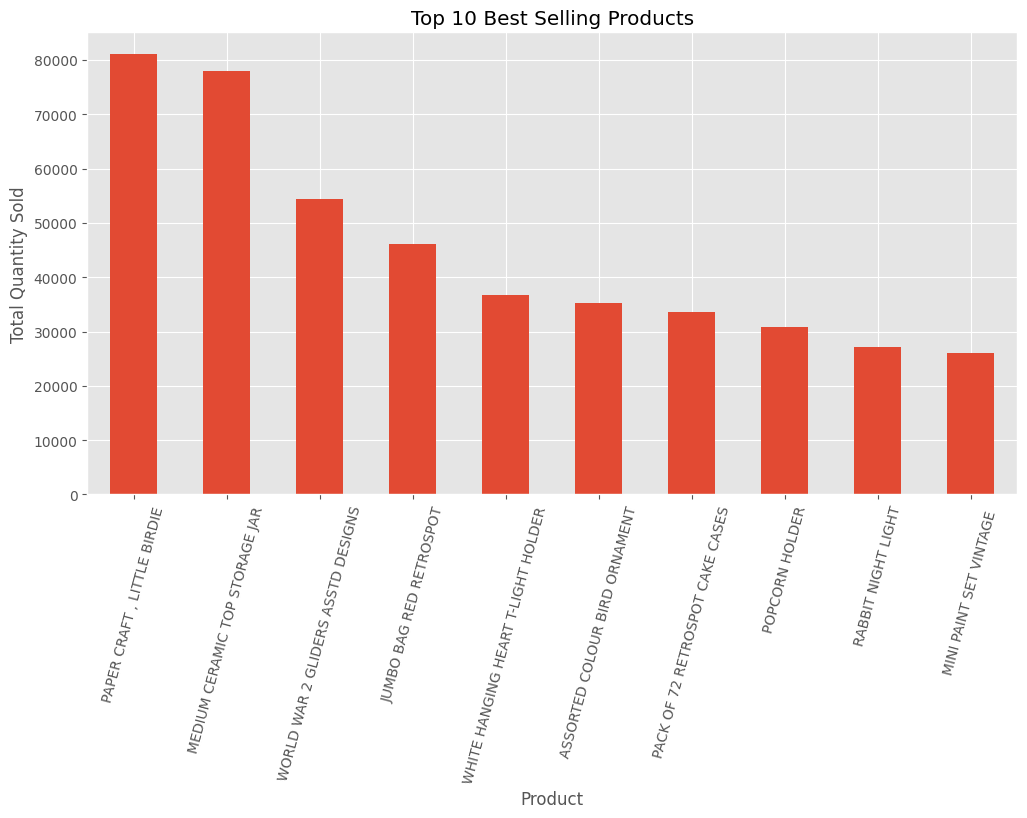

In [36]:
plt.figure(figsize=(12,6))

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=75)

plt.show()

## Top Selling Products

- The chart displays the top 10 best-selling products.
- These products have the highest sales quantity.
- They are the most popular items among customers.

In [37]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")

In [38]:
monthly_sales = df_clean.groupby("Month")["InvoiceNo"].count()

monthly_sales

Month
2022-12    25670
2023-01    20988
2023-02    19706
2023-03    26870
2023-04    22433
2023-05    28073
2023-06    26926
2023-07    26580
2023-08    26790
2023-09    39669
2023-10    48793
2023-11    63168
2023-12    17026
Freq: M, Name: InvoiceNo, dtype: int64

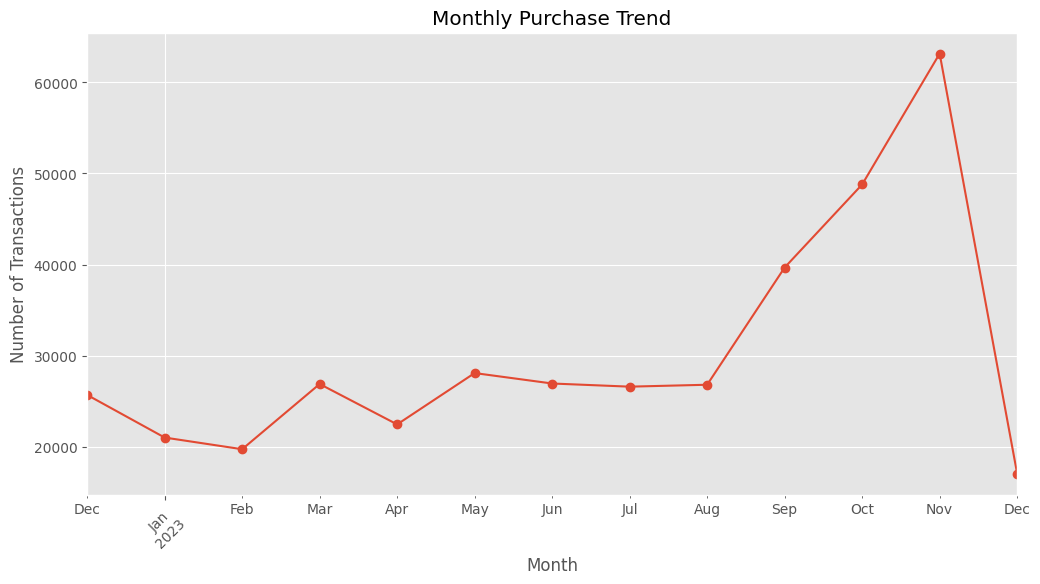

In [39]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

## Monthly Purchase Trend

- The line chart shows monthly transaction trends.
- It helps identify seasonal increases or decreases in purchases.

In [40]:
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

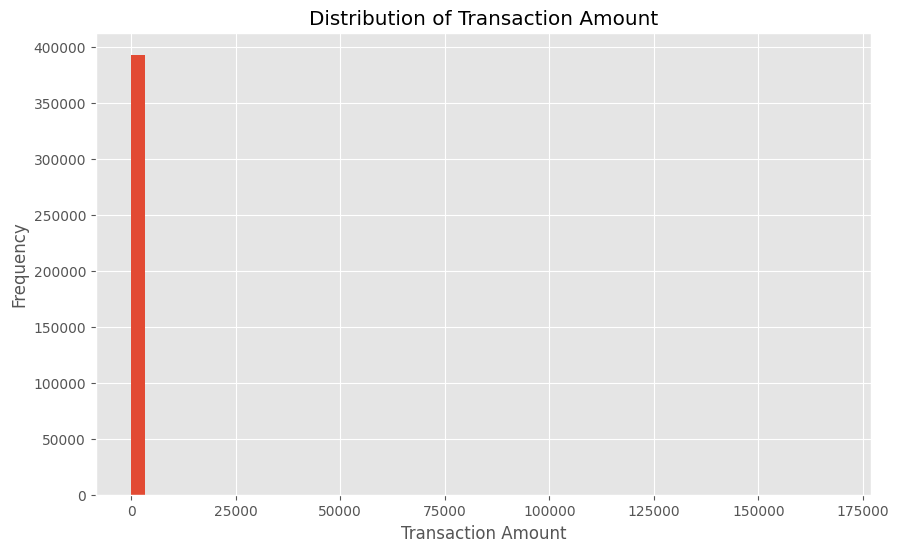

In [41]:
plt.figure(figsize=(10,6))

plt.hist(df_clean["TotalAmount"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

## Monetary Distribution

- Most transactions have relatively low purchase amounts.
- Only a few transactions have very high values.
- The distribution is positively skewed.

In [42]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2023-12-10 12:50:00')

In [43]:
rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [44]:
rfm.shape

(4338, 3)

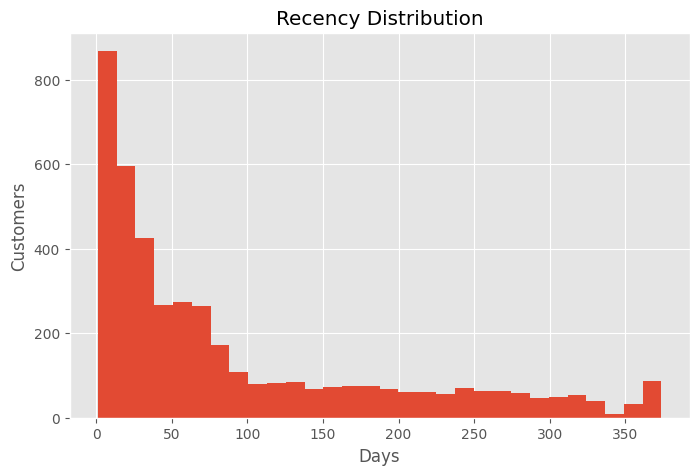

In [45]:
plt.figure(figsize=(8,5))

plt.hist(rfm["Recency"], bins=30)

plt.title("Recency Distribution")
plt.xlabel("Days")
plt.ylabel("Customers")

plt.show()

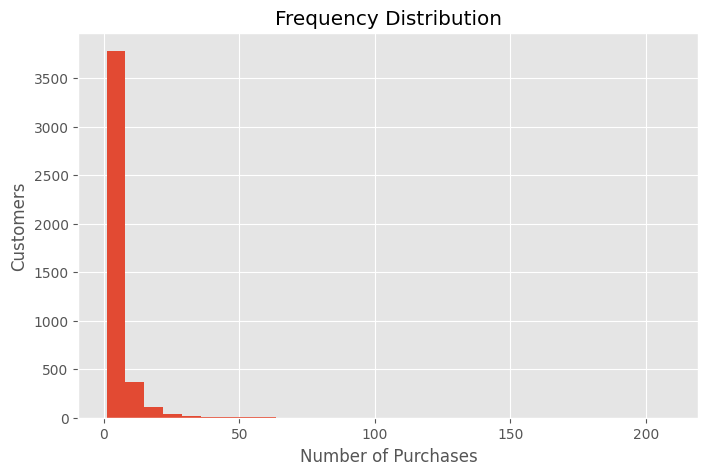

In [46]:
plt.figure(figsize=(8,5))

plt.hist(rfm["Frequency"], bins=30)

plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Customers")

plt.show()

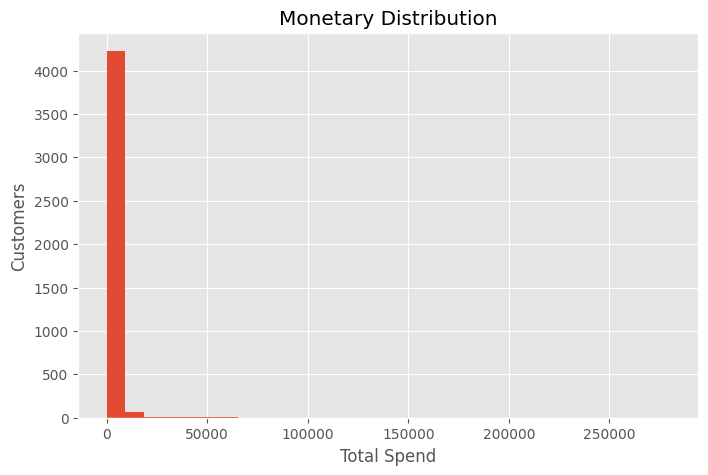

In [47]:
plt.figure(figsize=(8,5))

plt.hist(rfm["Monetary"], bins=30)

plt.title("Monetary Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Customers")

plt.show()

## RFM Analysis

- Recency measures how recently a customer made a purchase.
- Frequency represents the number of unique purchases made by each customer.
- Monetary indicates the total amount spent by each customer.
- These three features are used for customer segmentation.

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [49]:
from sklearn.cluster import KMeans

In [50]:
inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

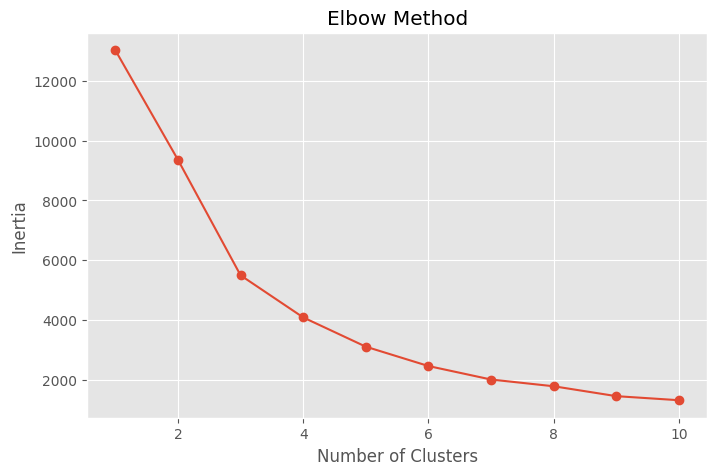

In [51]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

## Elbow Method

- The Elbow Method helps determine the optimal number of clusters.
- The point where the curve starts to bend is considered the best number of clusters.

In [52]:
n_clusters = 3

In [53]:
kmeans = KMeans(n_clusters=3, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [54]:
rfm["Cluster"].value_counts()

Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64

In [55]:
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,40.983906,4.852677,2005.830431
1,246.023788,1.582800,629.357439
2,7.142857,80.214286,122748.792143


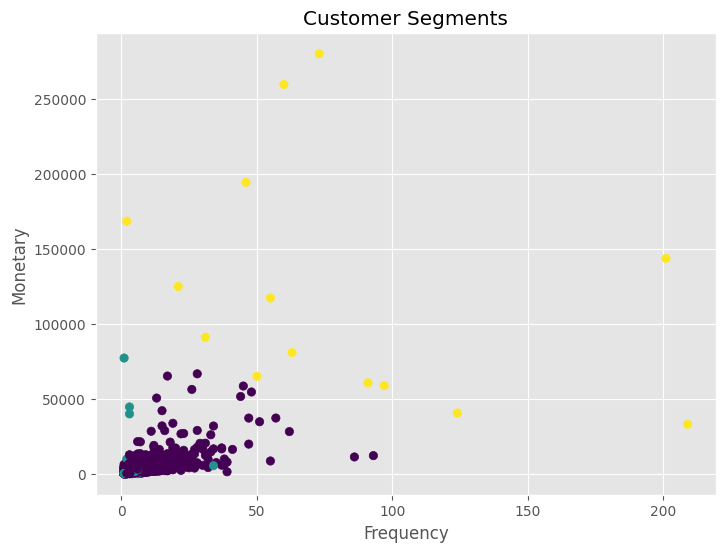

In [56]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

## Customer Cluster Profiles

- Customers were divided into **3 clusters** using the K-Means algorithm.
- Clustering was based on Recency, Frequency, and Monetary (RFM) values.
- The scatter plot visualizes the different customer segments.
- These customer segments can help businesses target marketing campaigns more effectively.

In [57]:
customer_product = df_clean.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    fill_value=0
)

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

In [59]:
product_similarity = cosine_similarity(customer_product.T)

In [60]:
similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

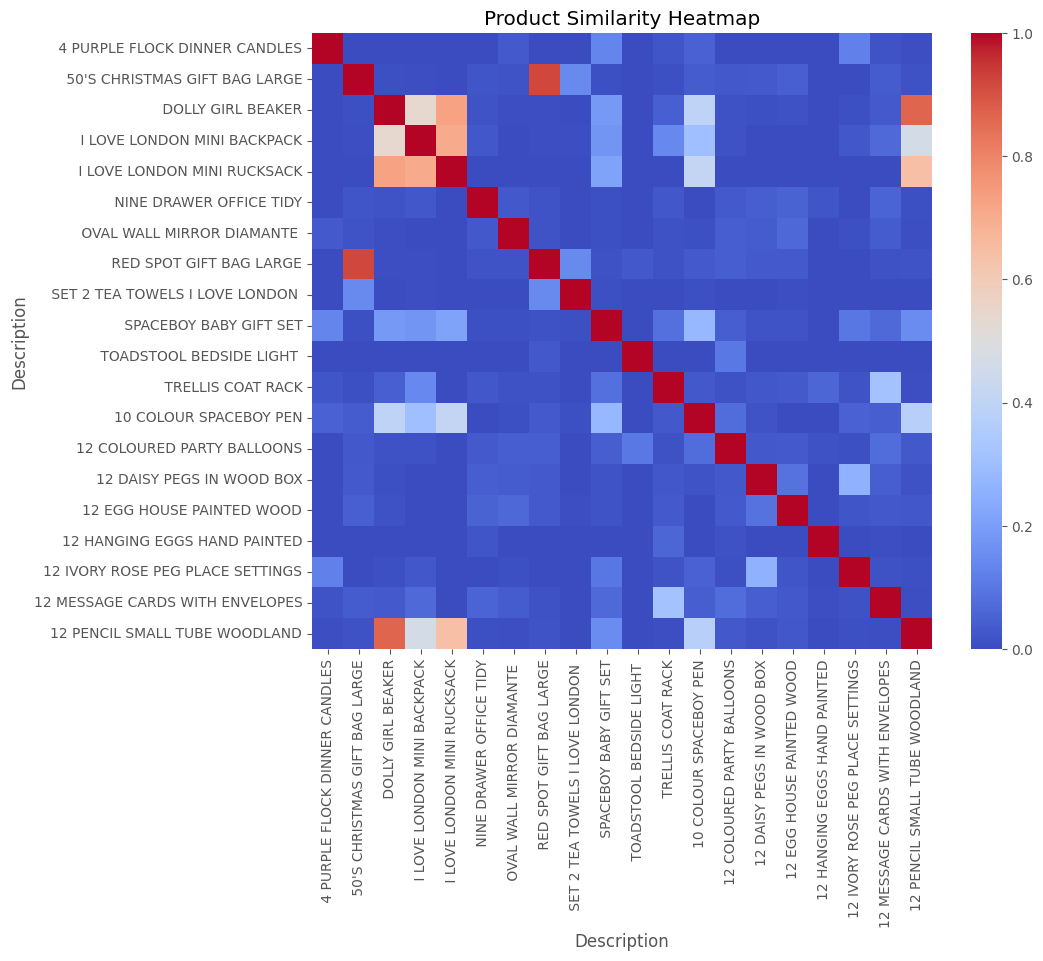

In [61]:
plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_df.iloc[:20, :20],
    cmap="coolwarm"
)

plt.title("Product Similarity Heatmap")

plt.show()

In [62]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(similarity_df, "similarity_matrix.pkl")

['similarity_matrix.pkl']

# Step 4: Clustering Methodology

## Feature Engineering

To prepare the data for customer segmentation, three important features were created using the cleaned transaction dataset.

### Recency (R)
Number of days since the customer's last purchase.

### Frequency (F)
Total number of unique transactions made by each customer.

### Monetary (M)
Total amount spent by each customer.

These three features together form the RFM model, which is widely used for customer segmentation.

In [63]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### RFM Table

The RFM table contains one row for each customer and summarizes:

- Recency
- Frequency
- Monetary Value

These features will be used for clustering customers.

## Standardization

The RFM features have different scales.

For example:

- Monetary can be thousands.
- Frequency may be only a few purchases.
- Recency is measured in days.

Therefore, StandardScaler is used so that all features contribute equally to clustering.

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

## Choosing the Clustering Algorithm

K-Means clustering was selected because it is simple, efficient, and widely used for customer segmentation.

The optimal number of clusters was determined using the Elbow Method.

In [65]:
from sklearn.cluster import KMeans

inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

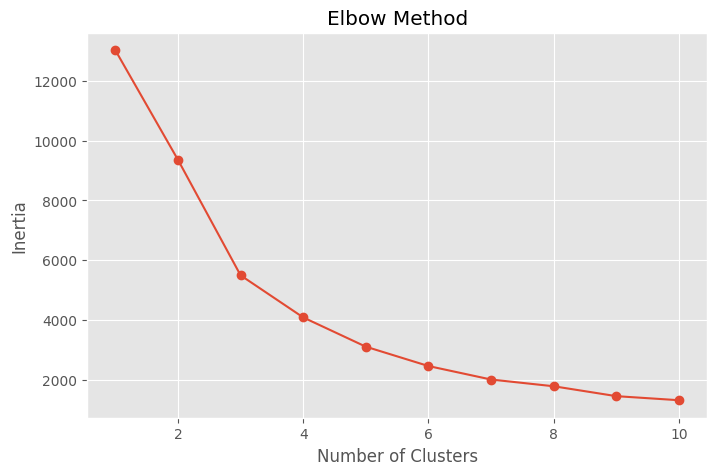

In [66]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

### Observation

The elbow point appears around **3 clusters**, indicating that dividing customers into three groups provides a good balance between simplicity and model performance.

In [67]:
kmeans = KMeans(n_clusters=3, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [68]:
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,40.983906,4.852677,2005.830431
1,246.023788,1.582800,629.357439
2,7.142857,80.214286,122748.792143


In [69]:
segment_names = {
    0: "Regular",
    1: "At-Risk",
    2: "High-Value"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,1,At-Risk
12347.0,2,7,4310.00,0,Regular
12348.0,75,4,1797.24,0,Regular
12349.0,19,1,1757.55,0,Regular
12350.0,310,1,334.40,1,At-Risk


In [70]:
rfm["Segment"].value_counts()

Segment
Regular       3231
At-Risk       1093
High-Value      14
Name: count, dtype: int64

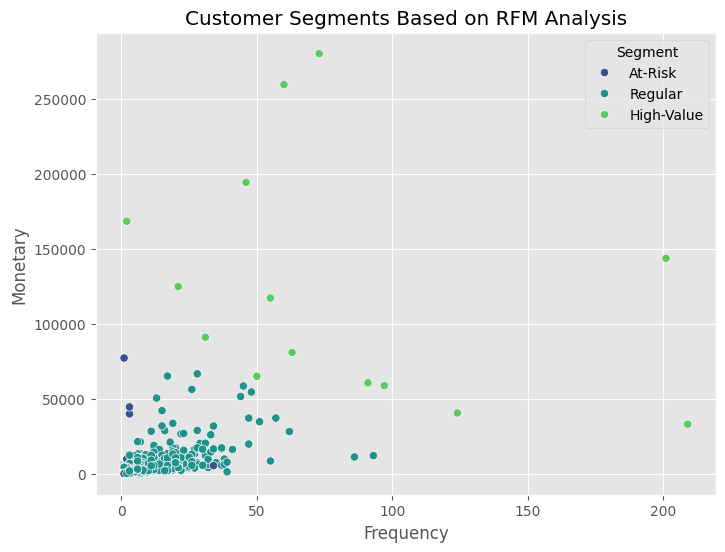

In [71]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="viridis"
)

plt.title("Customer Segments Based on RFM Analysis")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

# Customer Cluster Interpretation

The K-Means algorithm divided customers into **3 segments**.

### High-Value Customers
- Purchase frequently
- Spend the highest amount
- Purchased recently
- These customers are the most valuable.

### Regular Customers
- Moderate purchase frequency
- Moderate spending
- Purchase occasionally
- These customers should be encouraged through loyalty programs.

### At-Risk Customers
- Have not purchased for a long time
- Spend less
- Purchase infrequently
- These customers should be targeted with promotional offers to encourage them to return.

In [72]:
from sklearn.metrics import silhouette_score


In [73]:
silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.5604013068318398, 0.5853238625904468, 0.6162275299061803, 0.6165002474679847, 0.5982885618366588, 0.5170880799084383, 0.49121068260754397, 0.4784383467130572, 0.4448163678156714]


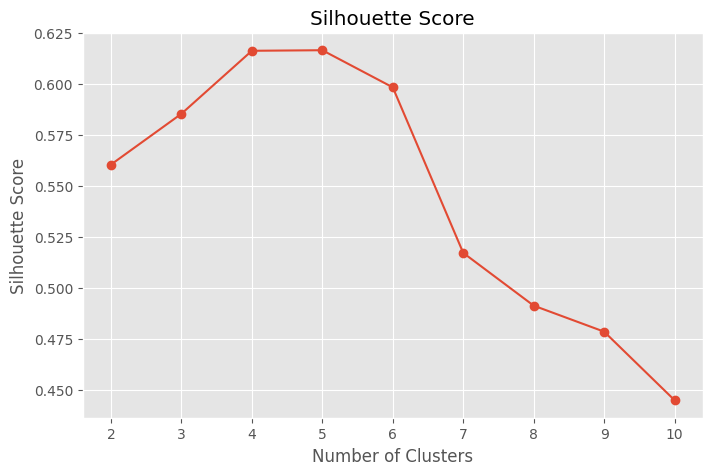

In [74]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [75]:
best_k = silhouette_scores.index(max(silhouette_scores)) + 2

print("Best number of clusters:", best_k)

Best number of clusters: 5


## Silhouette Score

The Silhouette Score measures how well-separated the clusters are.

- The score ranges from **-1 to 1**.
- A higher score indicates better-defined clusters.
- The optimal number of clusters is chosen based on the highest Silhouette Score.

In this project, the Elbow Method and Silhouette Score were both used to validate the selection of **3 clusters** for customer segmentation.

In [76]:
segment_labels = {
    0: "Regular",
    1: "At-Risk",
    2: "High-Value"
}

rfm["Segment"] = rfm["Cluster"].map(segment_labels)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,1,At-Risk
12347.0,2,7,4310.00,0,Regular
12348.0,75,4,1797.24,0,Regular
12349.0,19,1,1757.55,0,Regular
12350.0,310,1,334.40,1,At-Risk


In [77]:
rfm["Segment"].value_counts()

Segment
Regular       3231
At-Risk       1093
High-Value      14
Name: count, dtype: int64

## Cluster Interpretation

After applying K-Means clustering, the customers were divided into **3 customer segments** based on their RFM values.

### High-Value Customers
- Very recent purchases (low Recency)
- High purchase frequency
- Highest total spending
- These customers are the most valuable to the business.

### Regular Customers
- Moderate purchase frequency
- Moderate spending
- Purchase products regularly but are not premium customers.

### At-Risk Customers
- Long time since last purchase (high Recency)
- Low purchase frequency
- Low spending
- These customers may stop purchasing and can be targeted with promotional offers.

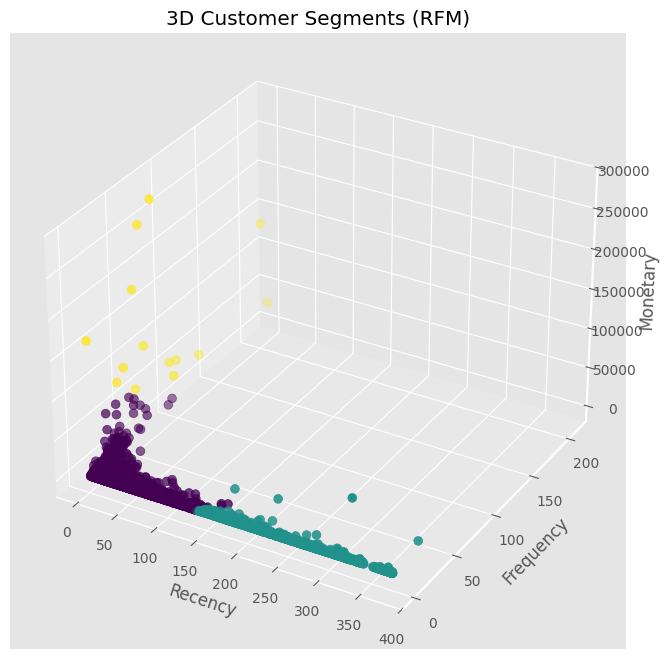

In [78]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis",
    s=40
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("3D Customer Segments (RFM)")

plt.show()

## Customer Cluster Visualization

A scatter plot was used to visualize the customer segments created by the K-Means clustering algorithm.

- **High-Value Customers**: High frequency, high spending, and recent purchases.
- **Regular Customers**: Moderate purchase frequency and spending.
- **At-Risk Customers**: Low purchase frequency, low spending, and a long time since their last purchase.

The visualization helps understand how customers are grouped based on their purchasing behavior using RFM analysis.

In [79]:
import joblib

In [80]:
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [81]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [82]:
joblib.dump(similarity_df, "similarity_matrix.pkl")

['similarity_matrix.pkl']

## Saving the Model

The trained machine learning models were saved using the **Joblib** library.

The following files were created:

- **kmeans_model.pkl** – Stores the trained K-Means clustering model.
- **scaler.pkl** – Stores the StandardScaler used for feature scaling.
- **similarity_matrix.pkl** – Stores the product similarity matrix used for product recommendations.

These files will be loaded in the Streamlit application to make real-time customer segmentation and product recommendations without retraining the models.

In [83]:
customer_product = df_clean.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    fill_value=0
)

customer_product.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
from sklearn.metrics.pairwise import cosine_similarity

In [85]:
product_similarity = cosine_similarity(customer_product.T)

In [86]:
similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000106,0.000494,0.000000,0.000000,0.031646,0.000000,0.000272,0.134742,...,0.0,0.002012,0.028527,0.002462,0.0,0.005989,0.0,0.039433,0.00000,0.001852
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.009122,0.004511,0.000000,0.020504,0.016754,0.918932,0.145842,0.008422,...,0.0,0.001864,0.021446,0.011945,0.0,0.014968,0.0,0.010439,0.00000,0.031379
DOLLY GIRL BEAKER,0.000106,0.009122,1.000000,0.536122,0.728436,0.017888,0.005196,0.007484,0.002644,0.186645,...,0.0,0.000174,0.009783,0.367750,0.0,0.251580,0.0,0.455007,0.00036,0.015559
I LOVE LONDON MINI BACKPACK,0.000494,0.004511,0.536122,1.000000,0.705221,0.025421,0.001527,0.004645,0.007080,0.172236,...,0.0,0.001621,0.008273,0.353233,0.0,0.239391,0.0,0.453407,0.00000,0.016661
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.728436,0.705221,1.000000,0.000000,0.000000,0.000000,0.000000,0.213768,...,0.0,0.000000,0.000000,0.490886,0.0,0.330277,0.0,0.615980,0.00000,0.000000


In [87]:
def recommend_products(product_name, top_n=5):

    if product_name not in similarity_df.index:
        return "Product not found."

    similar_products = similarity_df[product_name].sort_values(ascending=False)

    recommendations = similar_products.iloc[1:top_n+1]

    return recommendations

In [88]:
df_clean["Description"].unique()[:20]

<ArrowStringArray>
[ 'WHITE HANGING HEART T-LIGHT HOLDER',                 'WHITE METAL LANTERN',
      'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE',
      'RED WOOLLY HOTTIE WHITE HEART.',        'SET 7 BABUSHKA NESTING BOXES',
   'GLASS STAR FROSTED T-LIGHT HOLDER',              'HAND WARMER UNION JACK',
           'HAND WARMER RED POLKA DOT',       'ASSORTED COLOUR BIRD ORNAMENT',
          'POPPY'S PLAYHOUSE BEDROOM ',           'POPPY'S PLAYHOUSE KITCHEN',
   'FELTCRAFT PRINCESS CHARLOTTE DOLL',             'IVORY KNITTED MUG COSY ',
  'BOX OF 6 ASSORTED COLOUR TEASPOONS',       'BOX OF VINTAGE JIGSAW BLOCKS ',
      'BOX OF VINTAGE ALPHABET BLOCKS',            'HOME BUILDING BLOCK WORD',
            'LOVE BUILDING BLOCK WORD',         'RECIPE BOX WITH METAL HEART']
Length: 20, dtype: str

In [89]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

Description
GIN + TONIC DIET METAL SIGN           0.935865
TEA TIME TEA TOWELS                   0.925193
FAIRY CAKE FLANNEL ASSORTED COLOUR    0.914906
DOORMAT FAIRY CAKE                    0.888526
RED HANGING HEART T-LIGHT HOLDER      0.258615
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

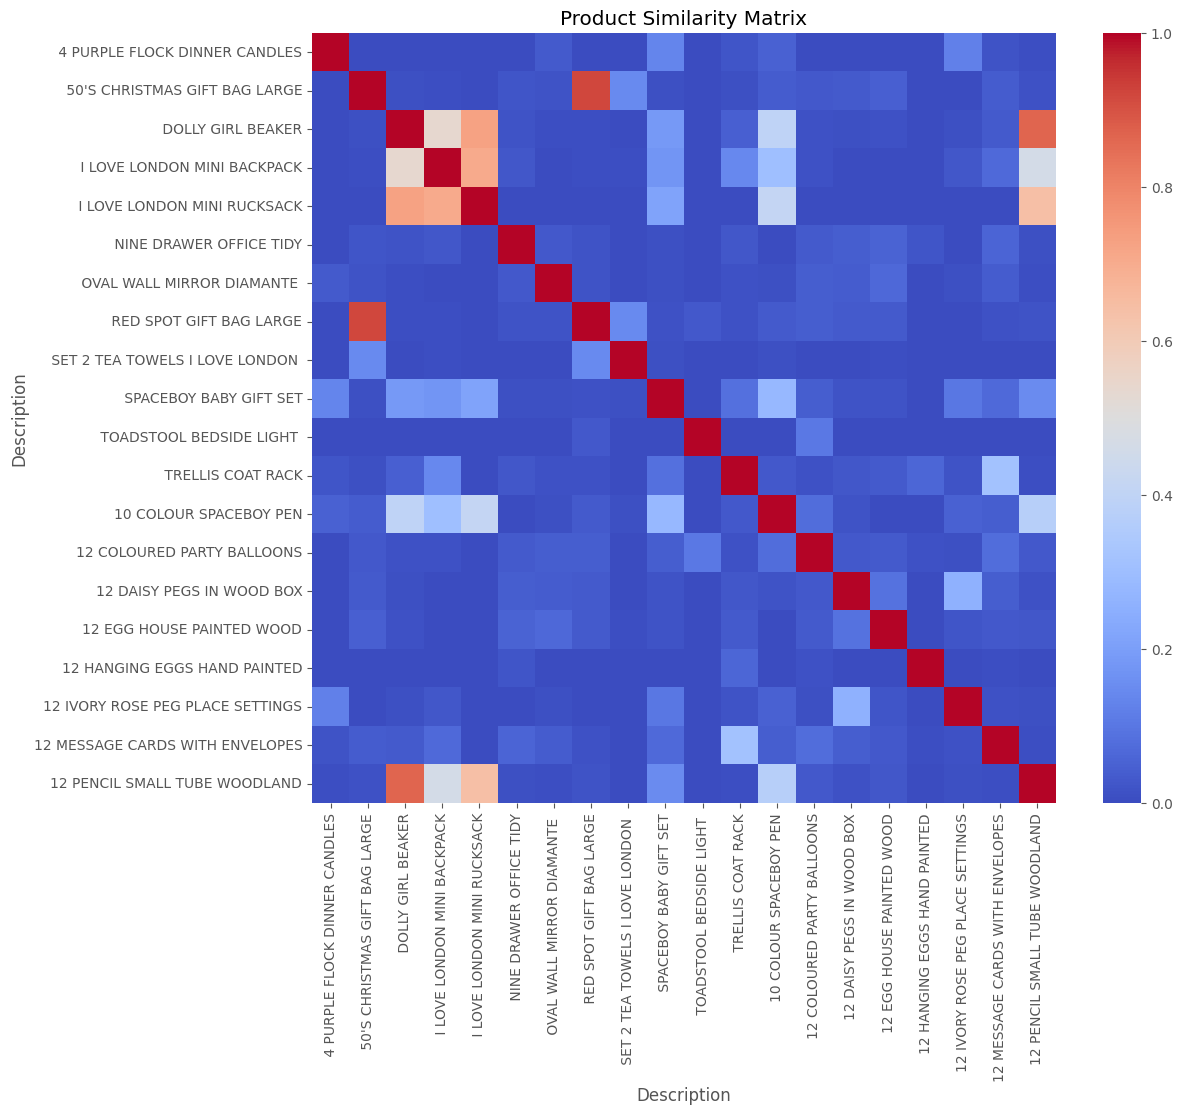

In [90]:
plt.figure(figsize=(12,10))

sns.heatmap(
    similarity_df.iloc[:20, :20],
    cmap="coolwarm"
)

plt.title("Product Similarity Matrix")

plt.show()

In [91]:
import joblib

joblib.dump(similarity_df, "similarity_matrix.pkl")

['similarity_matrix.pkl']

# Recommendation System

## Item-based Collaborative Filtering

An item-based collaborative filtering recommendation system was developed.

### Methodology

1. Created a Customer–Product matrix.
2. Computed cosine similarity between products.
3. Identified products with similar purchasing patterns.
4. Recommended the top 5 similar products for any selected product.

### Similarity Metric

Cosine Similarity was used because it effectively measures the similarity between products based on customer purchase history.

The trained similarity matrix was saved as **similarity_matrix.pkl** for use in the Streamlit application.

In [92]:
from sklearn.cluster import KMeans
import joblib

# Train final model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(rfm_scaled)

# Save the correct model
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [93]:
from sklearn.cluster import KMeans
import joblib

# Train the final KMeans model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(rfm_scaled)

# Save the model (this replaces the old one)
joblib.dump(kmeans, "kmeans_model.pkl")

print("New model saved successfully!")

New model saved successfully!
